## UCS619 Quantum Computing: Lab Assignment-7
## Applications of  Entanglement

Name: Smarth Kaushal | Roll No. 102497023 | Group: 3Q21 | Lab Instructor: Dr. Samya Muhuri

## Experiment 1: Superdense Coding Protocol

In [16]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

def create_superdense_circuit(bits):
    qc = QuantumCircuit(2)

    # Step-1. Create a Bell pair |phi+>
    qc.h(0)
    qc.cx(0, 1)
    qc.barrier()

    # Step-2. Alice Encodes the message
    if bits == "00":
        pass               
    elif bits == "01":
        qc.x(0)             
    elif bits == "10":
        qc.z(0)             
    elif bits == "11":
        qc.z(0)
        qc.x(0)             

    qc.barrier()

    # Step-3. Transmission
    # Alice sends qubit 0 to Bob. 

    # Step-4. Bob decodes the message
    qc.cx(0, 1)
    qc.h(0)

    # Step-5. Measurement
    qc.measure_all()
    return qc

Message to send: 01
Quantum circuit:


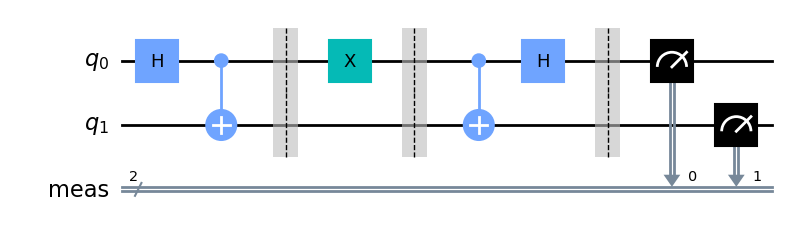

Resulting measurement at Bob's end: {'10': 1024}


In [ ]:
# Example: Sending the message "01"
msg = "01"
circuit = create_superdense_circuit(msg)

# Run the Simulation
simulator = AerSimulator()
result = simulator.run(circuit).result()
counts = result.get_counts()

print(f"Message to send: {msg}")
print("Quantum circuit:")
display(circuit.draw('mpl', style='clifford'))
print(f"Resulting measurement at Bob's end: {counts}")


Our simulator simulates a perfect quantum computer. We can see that, without errors, we get a 100% chance of measuring the correct message.

Important Note: Qiskit uses Little Endian notation when ordering qubits and bits, meaning qubit 0 is the rightmost bit in the bitstrings.
Hence, measurement output gives `ji` instead of `ij` bits.

## Experiment 2: Quantum Teleportation

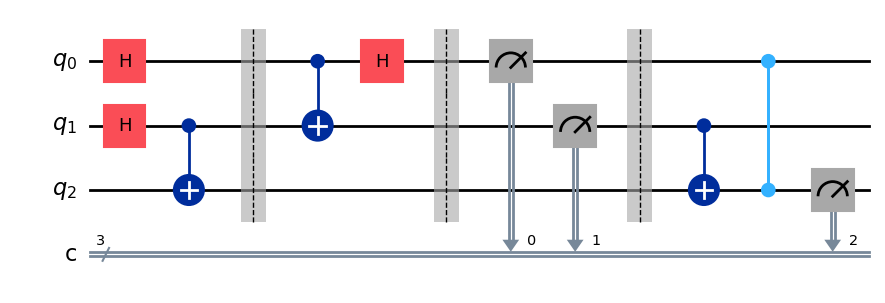

Measurement counts:  {'111': 124, '010': 128, '101': 120, '000': 133, '110': 116, '011': 150, '100': 113, '001': 140}


In [18]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

qc = QuantumCircuit(3, 3)

# Step 1: Prepare state to teleport (|+⟩ state)
qc.h(0)

# Step 2: Create Bell pair 
qc.h(1)
qc.cx(1, 2)
qc.barrier()

# Step 3: Bell measurement
qc.cx(0, 1)
qc.h(0)
qc.barrier()

qc.measure(0, 0)
qc.measure(1, 1)
qc.barrier()

# Step 4: Cnoditional operations (State reconstruction)
qc.cx(1, 2)
qc.cz(0, 2)

# Step 5: Measure Bob's qubit (q2)
qc.measure(2, 2)

display(qc.draw('mpl'))

sim = AerSimulator()
result = sim.run(qc, shots=1024).result()
counts = result.get_counts()
print("Measurement counts: ", counts)

## Experiment 3: Quantum Coin Game (Penny flip Game)

### 3.1 Understanding the Game

The Quantum Coin Toss is a game played between a Quantum Computer (Alice) and a Classical Player (Bob). 

**Rules of this game:-** <a id="rules"></a>
 1. Quantum Computer plays a move but it is not revealed to the Opponent(Human).
 2. Opponent(Human) plays a move and it is also not revealed to the Quantum Computer.
 3. Finally Quantum Computer plays a move.
 4. Results are shown. If its heads, then Quantum Computer wins. Else, Opponent(Human) wins.
 
**NOTE**: "Playing a move" refers to "Flipping the coin" and we consider the coin as fair coin.

**The Quantum Strategy:**
* The coin is initialized to the $|0\rangle$ "heads" state.

* The computer plays, applying the Hadamard $H$ operator to the coin (operators are applied using matrix multiplication). 
$$H|0\rangle = \frac{1}{\sqrt2}(|0\rangle + |1\rangle)$$

The coin enters the $H|0\rangle = |+\rangle = \frac{1}{\sqrt{2}} \begin{bmatrix}  1 \\ 1 \end{bmatrix}$ state.


* The human plays, choosing whether to flip the coin (apply the $X$ operator) or do nothing (apply the $I$ operator). However, since the $X$ operator just flips the state vector upside down, $X$ has no effect. Same goes for $I$.

$$ X|+\rangle=|+\rangle $$
$$ I|+\rangle=|+\rangle $$

No matter what, the state is $|+\rangle$ after the human plays.

* The computer plays, applying the Hadamard $H$ operator again, taking the coin to the $|0⟩$ "heads" state.
$$H|+\rangle = |0\rangle$$



In [23]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

def play_quantum_coin_game(bob_flips=True):
    qc = QuantumCircuit(1, 1)
    
    # Alice's 1st Turn 
    # Alice puts the coin into superposition
    qc.h(0)
    qc.barrier()
    
    # Bob's Turn
    # Bob acts classically. If he flips, he applies X. 
    if bob_flips:
        qc.x(0)
    else:
        qc.id(0)
    qc.barrier()
    
    # Alice's 2nd Turn 
    # Alice 'undoes' the superposition to land back at Heads
    qc.h(0)
    
    # Result
    qc.measure(0, 0)
    return qc

# Simulate a game where Bob randomly chooses to flip
qc_game = play_quantum_coin_game(bob_flips=True)

# Run the simulation
sim = AerSimulator()
result = sim.run(qc_game, shots=1024).result()
counts = result.get_counts()
print("Counts: ", counts)

Counts:  {'0': 1024}


Outcome: 100% Heads ($|0\rangle$) — Quantum Computer Wins!

[Despite Bob's classical choice to flip or stay, the quantum player maintains control of the final state.]

### 3.2 Comparison of Efficiency


| Feature | Classical Strategy | Quantum Strategy |
| :--- | :--- | :--- |
| **Logic Basis** | Binary / Boolean ($0$ or $1$) | Superposition ($\|0\rangle$ and $\|1\rangle$) |
| **Control** | Bob can change the outcome. | Bob's actions are neutralized. |
| **Success Rate** | $50\%$ (Random Chance) | $100\%$ (Deterministic) |
| **Mathematical Basis** | Stochastic Probability | Unitary Transformation |

### 3.3 Conclusion

The experiment successfully demonstrates that quantum mechanics allows for strategies that are impossible in classical logic. While a classical game is limited to a $50/50$ probabilistic outcome, the quantum version allows Alice to achieve a Deterministic Win. By operating in the Hadamard basis, Alice effectively hides the state information from Bob's classical operations, proving that quantum interference provides a $100\%$ efficiency advantage over classical stochastic methods.

**END OF ASSIGNMENT**